# Imports # 

In [1]:
import pyspiel 
import numpy as np
from open_spiel.python.algorithms import cfr 
from open_spiel.python import rl_environment
from open_spiel.python import rl_tools 
from open_spiel.python.algorithms import random_agent
from open_spiel.python import policy as policy_lib
from open_spiel.python.algorithms import exploitability
from open_spiel.python.algorithms import evaluate_bots
from open_spiel.python.algorithms import cfr_br
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pickle 
import collections 
import re 

In [2]:
# Load the game
game = pyspiel.load_game("leduc_poker")

# CFR-CPT Policy # 

You don't need to run this again, just load the pre-computed average policy

In [3]:
def value_func(val, alpha=0.88, beta=0.88, lambdaa=2.25):
    if val >= 0: 
        return val ** alpha 
    return -lambdaa * ((-val) ** beta)

def tk_weight(p, gamma):
    """TK probability weighting function."""
    return p**gamma / (p**gamma + (1 - p)**gamma)**(1 / gamma)

def cpt_weights_wb(probs, utilities, player, gamma_gain=0.69, gamma_loss=0.61):
    """
    CPT decision weights following Tversky-Kahneman (1992):
    - Sort all outcomes worst-to-best in a single pass
    - Build cumulative probabilities from the bottom up
    - Switch between gamma+ and gamma- depending on sign of outcome
    - Decision weight = w(F_i) - w(F_{i-1})
    - Sum to 1 is guaranteed by the telescoping construction
    """
    u = utilities[:, player]
    n = len(probs)
    weights = np.zeros(n)

    # Single pass: sort all outcomes worst-to-best
    sorted_order = np.argsort(u)

    cum = 0.0
    prev_w = 0.0
    for idx in sorted_order:
        cum += probs[idx]
        gamma = gamma_gain if u[idx] >= 0 else gamma_loss
        w_cum = tk_weight(cum, gamma)
        weights[idx] = w_cum - prev_w
        prev_w = w_cum

    # Renormalization as numerical safety net only
    total = weights.sum()
    if total > 1e-12:
        weights /= total
    else:
        weights = probs.copy()

    return weights

def new_reach(so_far, player, action_prob):
  """Returns new reach probabilities."""
  new = np.array(so_far)
  new[player] *= action_prob
  return new

def calc_cfr(state, reach):
    """Updates regrets; returns utility for all players."""
    if state.is_terminal():
        utilities = np.array([value_func(u) for u in state.returns()])
        return utilities
    elif state.is_chance_node():
        return sum(
            prob * calc_cfr(state.child(action), new_reach(reach, -1, prob))
            for action, prob in state.chance_outcomes()
        )
    else:
        player = state.current_player()
        index = policy.state_index(state)
        legal = state.legal_actions()

        # --- Compute utilities after each action (recurse) ---
        utility = np.zeros((game.num_distinct_actions(), game.num_players()))
        for action in legal:
            prob = curr_policy[index][action]
            utility[action] = calc_cfr(
                state.child(action), new_reach(reach, player, prob)
            )

        # --- CPT-distorted probabilities for value computation ---
        # Extract probs and utilities only over legal actions
        legal_arr = np.array(legal)
        legal_probs = curr_policy[index][legal_arr]         # raw policy probs
        cpt_probs = cpt_weights_wb(legal_probs, utility[legal_arr], player)

        # --- Counterfactual weight (reach of all OTHER players) ---
        cfr_prob = np.prod(reach[:player]) * np.prod(reach[player + 1:])

        # --- Node value uses CPT-distorted probabilities ---
        # value[p] = sum_a  cpt_prob[a] * utility[a][p]
        value = np.zeros(game.num_players())
        for i, action in enumerate(legal):
            value += cpt_probs[i] * utility[action]

        # --- Regret update still uses raw utility vs CPT-weighted value ---
        for i, action in enumerate(legal):
            regrets[index][action] += cfr_prob * (
                utility[action][player] - value[player]
            )

        return value

In [ ]:
policy = policy_lib.TabularPolicy(game)
initial_state = game.new_initial_state()
curr_policy = policy.action_probability_array.copy()
regrets = np.zeros_like(policy.action_probability_array)
eval_steps = []
eval_nash_conv = []
for step in range(4097):
  # Compute regrets
  calc_cfr(initial_state, np.ones(1 + game.num_players()))

  # Find the new regret-matching policy
  floored_regrets = np.maximum(regrets, 1e-16)
  sum_floored_regrets = np.sum(floored_regrets, axis=1, keepdims=True)
  curr_policy = floored_regrets / sum_floored_regrets

  # Update the average policy
  lr = 1 / (1 + step)
  policy.action_probability_array *= (1 - lr)
  policy.action_probability_array += curr_policy * lr

  # Evaluate the average policy
  if step & (step-1) == 0:
    nc = exploitability.nash_conv(game, policy)
    eval_steps.append(step)
    eval_nash_conv.append(nc)
    print(f'Nash conv after step {step} is {nc}')

with open('cpt_cfr_policy.pkl', 'wb') as f:
    pickle.dump(policy, f)

# CFR Policy # 

You don't need to run this again, just load the pre-computed average policy

In [5]:
# create standard cfr policy 
solver = cfr.CFRSolver(game)

NUM_ITERATIONS = 4097
LOG_EVERY = 50
exploitabilities = []

for i in range(1, NUM_ITERATIONS+1):
    solver.evaluate_and_update_policy()

    if i % LOG_EVERY == 0:
        avg_policy = solver.average_policy()
        expl = exploitability.nash_conv(game, avg_policy)
        print(f"{i:>10}  {expl:>16.6f}")
        exploitabilities.append(expl)

average_policy = solver.average_policy()
final_expl = exploitability.nash_conv(game, average_policy)
print(f"\nFinal exploitability after {NUM_ITERATIONS} iterations: {final_expl:.6f}")
with open('standard_cfr_policy.pkl', 'wb') as f:
    pickle.dump(average_policy, f)

        50          0.378167
       100          0.191433
       150          0.125318
       200          0.107677
       250          0.080938
       300          0.071048
       350          0.061189
       400          0.052872
       450          0.049439
       500          0.043014
       550          0.041250
       600          0.039551
       650          0.035089
       700          0.032639
       750          0.030102
       800          0.028723
       850          0.027625
       900          0.028119
       950          0.026073
      1000          0.023636
      1050          0.023650
      1100          0.023105
      1150          0.021994
      1200          0.019832
      1250          0.019451
      1300          0.019560
      1350          0.018835
      1400          0.017724
      1450          0.018827
      1500          0.017138
      1550          0.014822
      1600          0.016057
      1650          0.015516
      1700          0.016502
      1750    

# Load CFR and CFR-CPT policies 

In [6]:
# load policy for standard cfr, so don't have to run it again 
with open("standard_cfr_policy.pkl", "rb") as f:
    standard_cfr_policy = pickle.load(f)

In [7]:
# load policy for modified cfr, so don't have to run it again 
with open('cpt_cfr_policy.pkl', 'rb') as f:
    cpt_cfr_policy = pickle.load(f)

# Test Exploitability of Policies # 

In [8]:
# exploitability of cfr-cpt policy

expl = exploitability.exploitability(game, cpt_cfr_policy)
print(f"Exploitability: {expl:.4f}")

# Or compute best response value directly
br_info = exploitability.best_response(game, cpt_cfr_policy, 1)
print(f"Best response value for player 1 against your policy: {br_info['best_response_value']:.4f}")

Exploitability: 0.7017
Best response value for player 1 against your policy: 0.6827


In [9]:
# exploitability of standard cfr average policy 

expl_cfr = exploitability.exploitability(game, standard_cfr_policy)
print(f"Exploitability of CFR average policy: {expl_cfr:.4f}")

br_info_cfr = exploitability.best_response(game, standard_cfr_policy, 1)
print(f"Best response value for player 1 against CFR average policy: {br_info_cfr['best_response_value']:.4f}")

Exploitability of CFR average policy: 0.0043
Best response value for player 1 against CFR average policy: 0.0909


# Agents # 

In [10]:
# Bot class to create a player that plays according to a given policy

class Bot: 
    def __init__(self, policy):
        self.policy = policy
        self.player_id = None # to be set at the start of each hand, depending on position

    def step(self, state):
        action_probs = self.policy.action_probabilities(state)
        actions, probs = zip(*action_probs.items())
        return random.choices(actions, probs)[0]

In [11]:
class ETCAgent:
    """
    Explore-Then-Commit agent. Explores for m hands using the given policy,
    then builds a best response against the estimated opponent strategy and commits to it.
    Best response is computed for both player positions (P0 and P1).
    No information-set simplification: each distinct information state string is its own key.
    """
    def __init__(self, exploration_policy, m):
        self.exploration_policy = exploration_policy
        self.m                  = m
        self.player_id          = None
        self.info_sets          = {}
        self.opponent_obs       = collections.defaultdict(lambda: {0: 0, 1: 0, 2: 0}) # game-specific
        self.info_state_visits  = collections.defaultdict(int)
        self.hands_played       = 0
        self.br_actions         = {}

    def _public_key(self, state):
        """Public history: skip the initial private card deals (one per player)."""
        return tuple(state.history()[game.num_players():])

    def _own_key(self, state):
        """Own info key: player_id + full information state string."""
        return (self.player_id, state.information_state_string(self.player_id))

    def observe_info_set(self, state, action):
        """Record opponent action, keyed by public history (no private cards)."""
        if self.br_actions:
            return
        key = self._public_key(state)
        self.opponent_obs[key][action] += 1
        self.info_state_visits[key] += 1

    def step(self, state):
        if self.hands_played < self.m:
            return self.explore(state)
        else:
            return self.commit(state)

    def explore(self, state):
        action_probs = self.exploration_policy.action_probabilities(state)
        actions, probs = zip(*action_probs.items())
        return random.choices(actions, probs)[0]

    def commit(self, state):
        key = self._own_key(state)
        if key not in self.br_actions:
            return self.explore(state)
        return self.br_actions[key]

    def estimate_opponent_strategy(self):
        """Normalize observed counts into probabilities."""
        for key, action_counts in self.opponent_obs.items():
            visits = self.info_state_visits[key]
            self.info_sets[key] = {action: count / visits for action, count in action_counts.items()}

    def end_hand(self):
        self.hands_played += 1
        if self.hands_played == self.m:
            self.estimate_opponent_strategy()
            self.build_best_response()

    def build_best_response(self):
        """Build best response for both player positions."""
        self.br_actions = {}
        original_player_id = self.player_id
        for pid in range(game.num_players()):
            self.player_id = pid
            self._compute_br(game.new_initial_state())
        self.player_id = original_player_id
        print(f"[ETC] Best response built over {len(self.br_actions)} info sets.")

    def _compute_br(self, state):
        """Recursively compute best response. Returns EV for self.player_id."""
        if state.is_terminal():
            return state.returns()[self.player_id]

        if state.is_chance_node():
            ev = 0.0
            for action, prob in state.chance_outcomes():
                ev += prob * self._compute_br(state.child(action))
            return ev

        legal_actions = state.legal_actions()

        if state.current_player() == self.player_id:
            key = self._own_key(state)
            best_action, best_ev = None, -float('inf')
            for action in legal_actions:
                ev = self._compute_br(state.child(action))
                if ev > best_ev:
                    best_ev, best_action = ev, action
            self.br_actions[key] = best_action
            return best_ev

        else:
            key = self._public_key(state)
            belief = self.info_sets.get(key, {a: 1/len(legal_actions) for a in legal_actions})
            ev = 0.0
            for action in legal_actions:
                p = belief.get(action, 0.0)
                if p > 0:
                    ev += p * self._compute_br(state.child(action))
            return ev


In [12]:
class ETCAgentV2(ETCAgent):
    """
    Extends ETCAgent with suit-irrelevance simplification.
    In Leduc poker suits are irrelevant, so J1/J2, Q1/Q2, K1/K2 are merged:
    - Community card is normalized to rank only in the public key
    - Own private card is normalized to rank only in the own key
    This reduces the number of distinct information sets to estimate and store,
    improving sample efficiency during the exploration phase.
    """

    def _public_key(self, state):
        """Public history with community card normalized to rank only (suit removed)."""
        h = state.history()
        s = game.new_initial_state()
        for action in h[:game.num_players()]:
            s.apply_action(action)
        norm = []
        for action in h[game.num_players():]:
            if s.is_chance_node():
                norm.append(action // 2)  # community card → rank only
            else:
                norm.append(action)       # player action, unchanged
            s.apply_action(action)
        return tuple(norm)

    def _own_key(self, state):
        """Own info key: player_id + hole card rank + rank-normalized public history."""
        our_rank = state.history()[self.player_id] // 2
        return (self.player_id, our_rank) + self._public_key(state)


# Simulation Function # 

In [13]:
# Uniform random policy to be used by the ETC agent during exploration
uniform_strategy = policy_lib.UniformRandomPolicy(game)

In [14]:
def run_simulation(Agent, agent_strategy=uniform_strategy, opponent_strategy=None, n=10000, n_repetitions=100, m_values=[1000, 2000, 4000, 6000, 8000, 9000, 9500]):
    if opponent_strategy is None:
        with open('cpt_cfr_policy.pkl', 'rb') as f:
            cfr_cpt_policy = pickle.load(f)
        cpt_agent = Bot(cfr_cpt_policy)
    else:
        cpt_agent = Bot(opponent_strategy)

    results        = {m: [] for m in m_values}
    commit_results = {m: [] for m in m_values}

    for m in m_values:
        for rep in range(n_repetitions):
            etc_agent = Agent(agent_strategy, m)
            etc_returns    = 0.0
            commit_returns = 0.0

            for i in range(n):
                if random.random() < 0.5:
                    cpt_player = 0
                else:
                    cpt_player = 1
                etc_agent.player_id = 1 - cpt_player

                state = game.new_initial_state()
                while not state.is_terminal():
                    if state.is_chance_node():
                        outcomes, probs = zip(*state.chance_outcomes())
                        action = random.choices(outcomes, weights=probs)[0]
                        state.apply_action(action)
                    elif state.current_player() == cpt_player:
                        action = cpt_agent.step(state)
                        etc_agent.observe_info_set(state, action)
                        state.apply_action(action)
                    else:
                        action = etc_agent.step(state)
                        state.apply_action(action)

                r = state.returns()
                etc_returns += r[1 - cpt_player]

                # hands_played >= m before end_hand means this hand was played in commit mode
                if etc_agent.hands_played >= etc_agent.m:
                    commit_returns += r[1 - cpt_player]

                etc_agent.end_hand()

            results[m].append(etc_returns / n)
            commit_results[m].append(commit_returns / (n - m))

        print(f"m={m} done — avg ETC return: {np.mean(results[m]):.4f}  |  avg commit return: {np.mean(commit_results[m]):.4f}")

    return {
        "results":              results,
        "commit_results":       commit_results,
        "m_values":             m_values,
        "n":                    n,
        "n_repetitions":        n_repetitions
    }


In [15]:
def show(data):
    results        = data["results"]
    commit_results = data["commit_results"]
    m_values       = data["m_values"]
    n              = data["n"]
    n_repetitions  = data["n_repetitions"]

    # --- Cumulative return summary ---
    cum_means = [np.mean(results[m]) * n for m in m_values]
    cum_stds  = [np.std(results[m])  * n for m in m_values]
    best_m    = m_values[int(np.argmax(cum_means))]

    print(f"\n{'m':>6}  {'cumulative return':>18}  {'std':>10}")
    print("-" * 40)
    for m, cm, cs in zip(m_values, cum_means, cum_stds):
        marker = "  <-- best" if m == best_m else ""
        print(f"{m:>6}  {cm:>18.2f}  {cs:>10.2f}{marker}")

    # --- Plot: overall vs commit-only average return ---
    means        = [np.mean(results[m])        for m in m_values]
    stds         = [np.std(results[m])         for m in m_values]
    commit_means = [np.mean(commit_results[m]) for m in m_values]
    commit_stds  = [np.std(commit_results[m])  for m in m_values]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(m_values, means, marker='o', linewidth=2, label='overall avg return')
    ax.fill_between(m_values,
                    [mu - s for mu, s in zip(means, stds)],
                    [mu + s for mu, s in zip(means, stds)],
                    alpha=0.2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Exploration threshold m')
    ax.set_ylabel('Average return per hand')
    ax.set_title(f'Overall avg return (n={n}, {n_repetitions} reps)')
    ax.legend()

    ax = axes[1]
    ax.plot(m_values, commit_means, marker='o', linewidth=2, color='tab:orange', label='commit-phase avg return')
    ax.fill_between(m_values,
                    [mu - s for mu, s in zip(commit_means, commit_stds)],
                    [mu + s for mu, s in zip(commit_means, commit_stds)],
                    alpha=0.2, color='tab:orange')
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Exploration threshold m')
    ax.set_ylabel('Average return per hand (commit phase only)')
    ax.set_title(f'Commit-phase avg return (n={n}, {n_repetitions} reps)')
    ax.legend()

    plt.tight_layout()
    plt.show()


In [16]:
def compare(data1, data2, label1=None, label2=None):
    """
    Plot results of two simulations on the same axes for direct comparison
    """

    def _extract(data):
        results        = data["results"]
        commit_results = data["commit_results"]
        m_values       = data["m_values"]
        means        = [np.mean(results[m])        for m in m_values]
        stds         = [np.std(results[m])         for m in m_values]
        commit_means = [np.mean(commit_results[m]) for m in m_values]
        commit_stds  = [np.std(commit_results[m])  for m in m_values]
        return m_values, means, stds, commit_means, commit_stds

    m1, means1, stds1, cm1, cs1 = _extract(data1)
    m2, means2, stds2, cm2, cs2 = _extract(data2)

    n            = data1["n"]
    n_repetitions = data1["n_repetitions"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(m1, means1, marker='o', linewidth=2, label=label1)
    ax.fill_between(m1, [mu - s for mu, s in zip(means1, stds1)],
                        [mu + s for mu, s in zip(means1, stds1)], alpha=0.2)
    ax.plot(m2, means2, marker='s', linewidth=2, label=label2)
    ax.fill_between(m2, [mu - s for mu, s in zip(means2, stds2)],
                        [mu + s for mu, s in zip(means2, stds2)], alpha=0.2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Exploration threshold m')
    ax.set_ylabel('Average return per hand')
    ax.set_title(f'Overall avg return (n={n}, {n_repetitions} reps)')
    ax.legend()

    ax = axes[1]
    ax.plot(m1, cm1, marker='o', linewidth=2, label=label1)
    ax.fill_between(m1, [mu - s for mu, s in zip(cm1, cs1)],
                        [mu + s for mu, s in zip(cm1, cs1)], alpha=0.2)
    ax.plot(m2, cm2, marker='s', linewidth=2, label=label2)
    ax.fill_between(m2, [mu - s for mu, s in zip(cm2, cs2)],
                        [mu + s for mu, s in zip(cm2, cs2)], alpha=0.2)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Exploration threshold m')
    ax.set_ylabel('Average return per hand (commit phase only)')
    ax.set_title(f'Commit-phase avg return (n={n}, {n_repetitions} reps)')
    ax.legend()

    plt.tight_layout()
    plt.show()


In [33]:
def simple_simulation(strategy1, strategy2, n=10000, n_repetitions=100):
    bot1 = Bot(strategy1)
    bot2 = Bot(strategy2)

    results = []

    for rep in range(n_repetitions):
        s1_return = 0.0

        for i in range(n):
            if random.random() < 0.5:
                s1_player = 0
            else:
                s1_player = 1

            state = game.new_initial_state()
            while not state.is_terminal():
                if state.is_chance_node():
                    outcomes, probs = zip(*state.chance_outcomes())
                    action = random.choices(outcomes, weights=probs)[0]
                    state.apply_action(action)
                elif state.current_player() == s1_player:
                    action = bot1.step(state)
                    state.apply_action(action)
                else:
                    action = bot2.step(state)
                    state.apply_action(action)

            s1_return += state.returns()[s1_player]

        results.append(s1_return / n)

    print(f"avg return for strategy1: {np.mean(results):.4f} ± {np.std(results):.4f}")

    return {
        "results":        results,
        "n":              n,
        "n_repetitions":  n_repetitions
    }


# Simulations # 

In [34]:
# CFR against CPT-CFR
data_cfr_vs_cpt = simple_simulation(strategy1=standard_cfr_policy, strategy2=cpt_cfr_policy, n=100000)

avg return for strategy1: 0.0142 ± 0.0102


[ETC] Best response built over 756 info sets.
[ETC] Best response built over 801 info sets.
[ETC] Best response built over 781 info sets.
[ETC] Best response built over 776 info sets.
[ETC] Best response built over 751 info sets.
[ETC] Best response built over 781 info sets.
[ETC] Best response built over 796 info sets.
[ETC] Best response built over 756 info sets.
[ETC] Best response built over 660 info sets.
[ETC] Best response built over 675 info sets.
[ETC] Best response built over 796 info sets.
[ETC] Best response built over 710 info sets.
[ETC] Best response built over 721 info sets.
[ETC] Best response built over 685 info sets.
[ETC] Best response built over 776 info sets.
[ETC] Best response built over 700 info sets.
[ETC] Best response built over 796 info sets.
[ETC] Best response built over 736 info sets.
[ETC] Best response built over 766 info sets.
[ETC] Best response built over 776 info sets.
[ETC] Best response built over 665 info sets.
[ETC] Best response built over 605

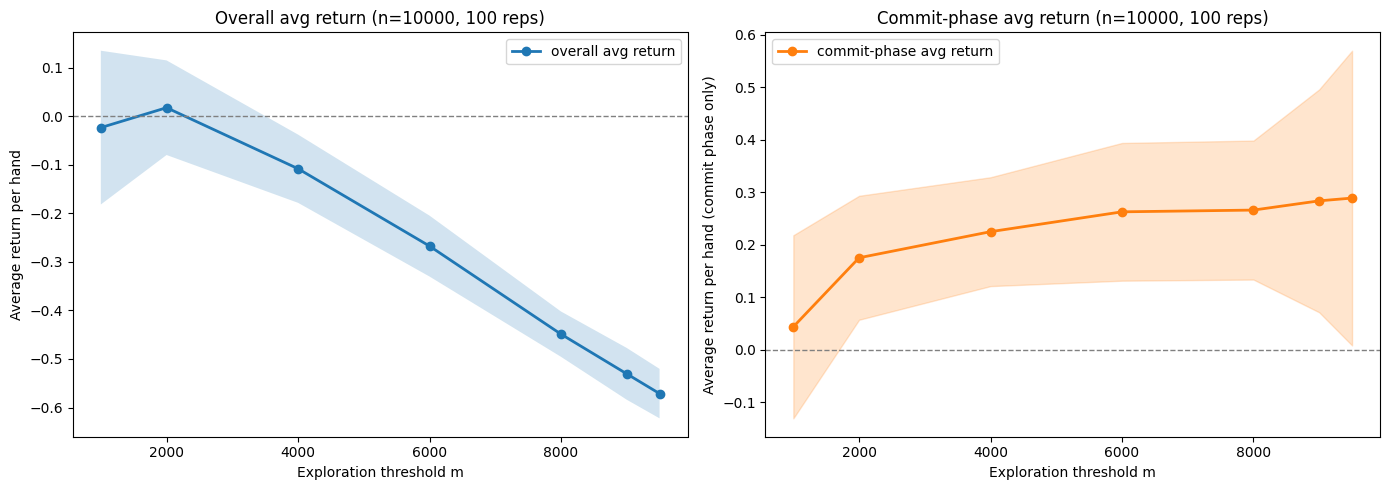

In [17]:
# Run simulation without the card abstraction
data_standard = run_simulation(ETCAgent)
show(data_standard)


[ETC] Best response built over 219 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 240 info sets.
[ETC] Best response built over 243 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 240 info sets.
[ETC] Best response built over 246 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 264 info sets.
[ETC] Best response built over 240 info sets.
[ETC] Best response built over 258 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 255 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 219 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 243 info sets.
[ETC] Best response built over 252 info sets.
[ETC] Best response built over 252

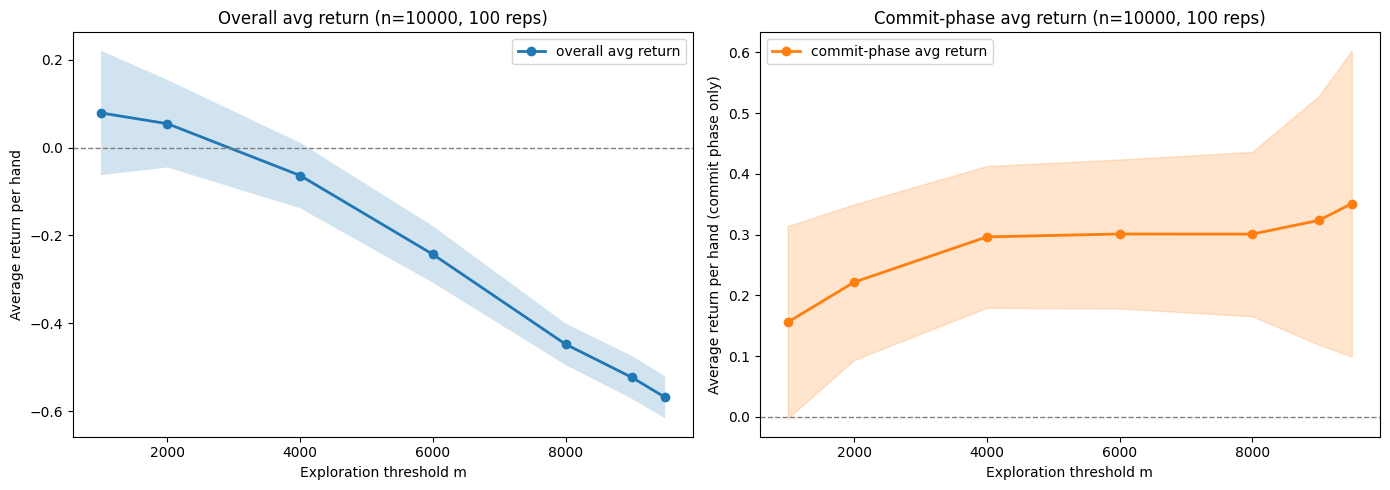

In [18]:
# Run simulation with the card abstraction (suit-irrelevance)
data_simplified = run_simulation(ETCAgentV2)
show(data_simplified)


[ETC] Best response built over 222 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 219 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 192 info sets.
[ETC] Best response built over 252 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 198 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 204 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 210

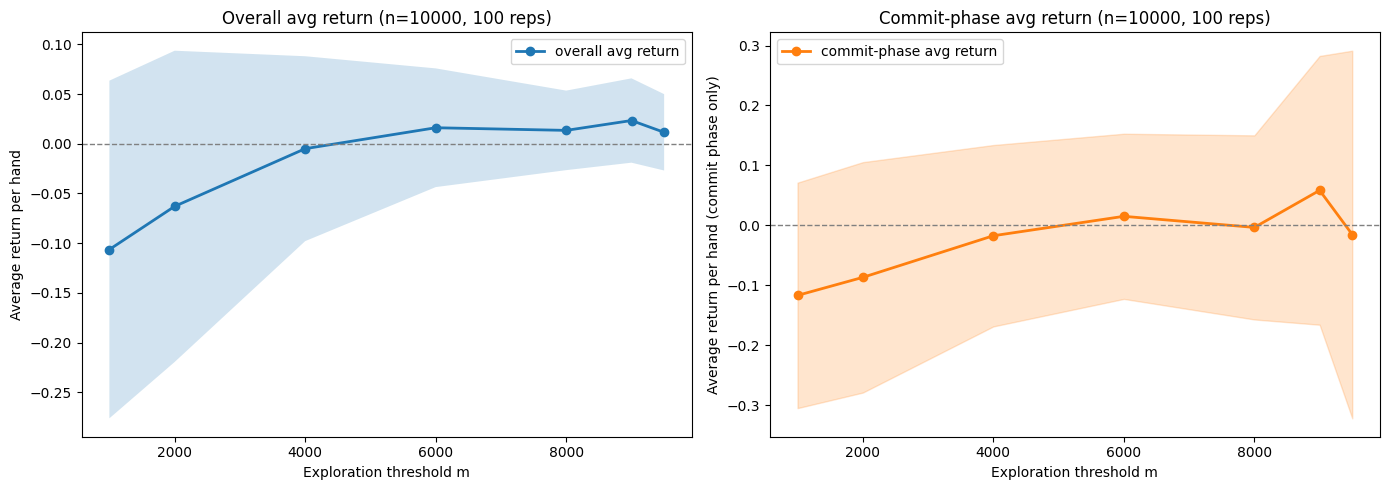

In [20]:
# Simulation with standard CFR policy as exploration strategy
data_simplified_cfr = run_simulation(ETCAgentV2, agent_strategy=standard_cfr_policy)
show(data_simplified_cfr)


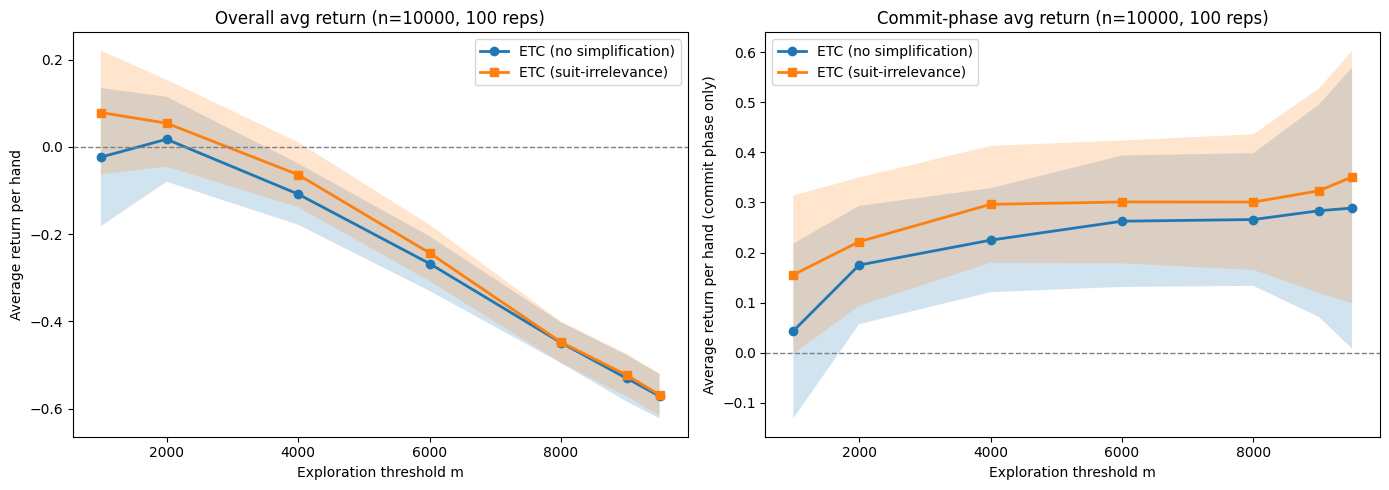

In [19]:
# Graph comparing directly the two versions of the ETC agent
compare(data_standard, data_simplified, label1="ETC (no simplification)", label2="ETC (suit-irrelevance)")

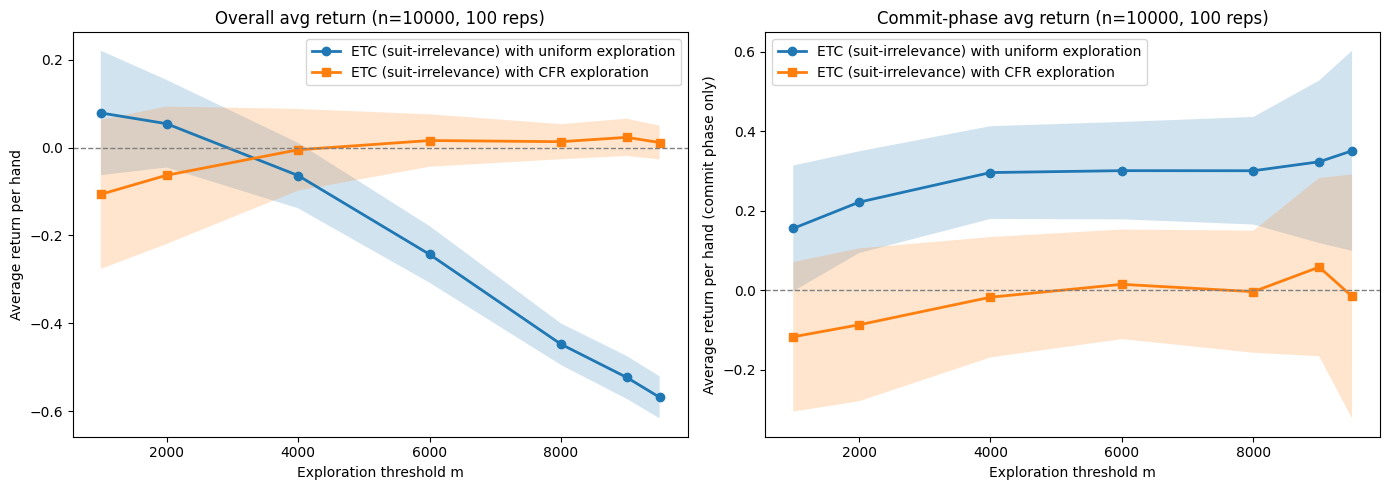

In [21]:
# Graph comparing directly ETCAgentV2 with uniform policy and with standard CFR policy as exploration strategy
compare(data_simplified, data_simplified_cfr, label1="ETC (suit-irrelevance) with uniform exploration", label2="ETC (suit-irrelevance) with CFR exploration")

[ETC] Best response built over 237 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 237 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 219 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 240 info sets.
[ETC] Best response built over 234 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 231

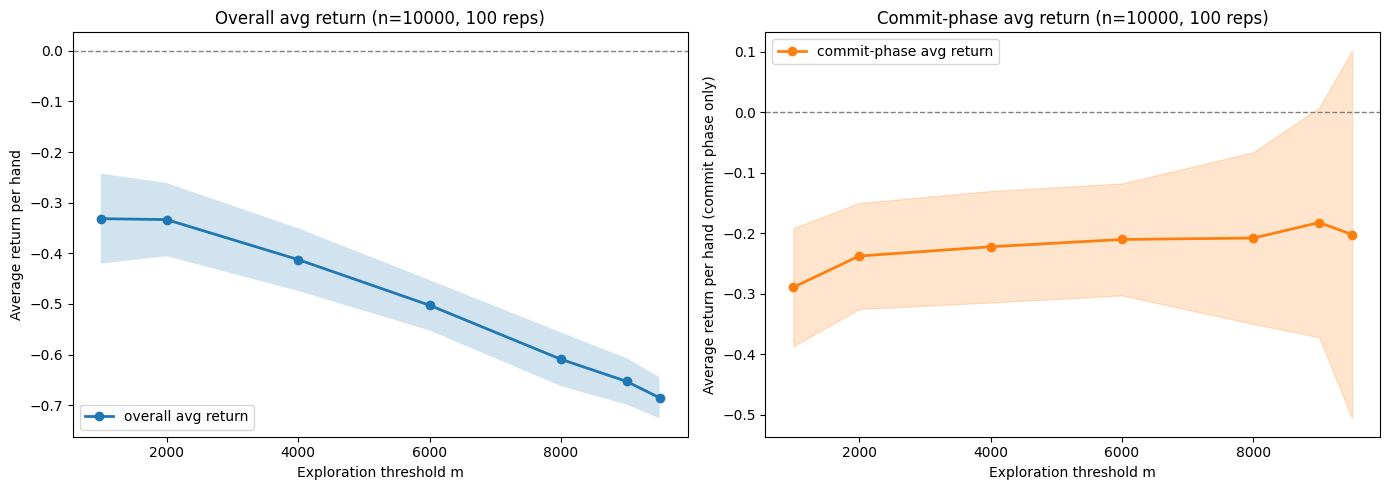

In [26]:
# Run simulation against standard CFR 
data_vs_cfr = run_simulation(ETCAgentV2, opponent_strategy=standard_cfr_policy)
show(data_vs_cfr)

[ETC] Best response built over 168 info sets.
[ETC] Best response built over 141 info sets.
[ETC] Best response built over 159 info sets.
[ETC] Best response built over 165 info sets.
[ETC] Best response built over 168 info sets.
[ETC] Best response built over 108 info sets.
[ETC] Best response built over 120 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 138 info sets.
[ETC] Best response built over 126 info sets.
[ETC] Best response built over 171 info sets.
[ETC] Best response built over 177 info sets.
[ETC] Best response built over 195 info sets.
[ETC] Best response built over 144 info sets.
[ETC] Best response built over 141 info sets.
[ETC] Best response built over 129 info sets.
[ETC] Best response built over 141 info sets.
[ETC] Best response built over 114 info sets.
[ETC] Best response built over 198 info sets.
[ETC] Best response built over 123 info sets.
[ETC] Best response built over 156 info sets.
[ETC] Best response built over 150

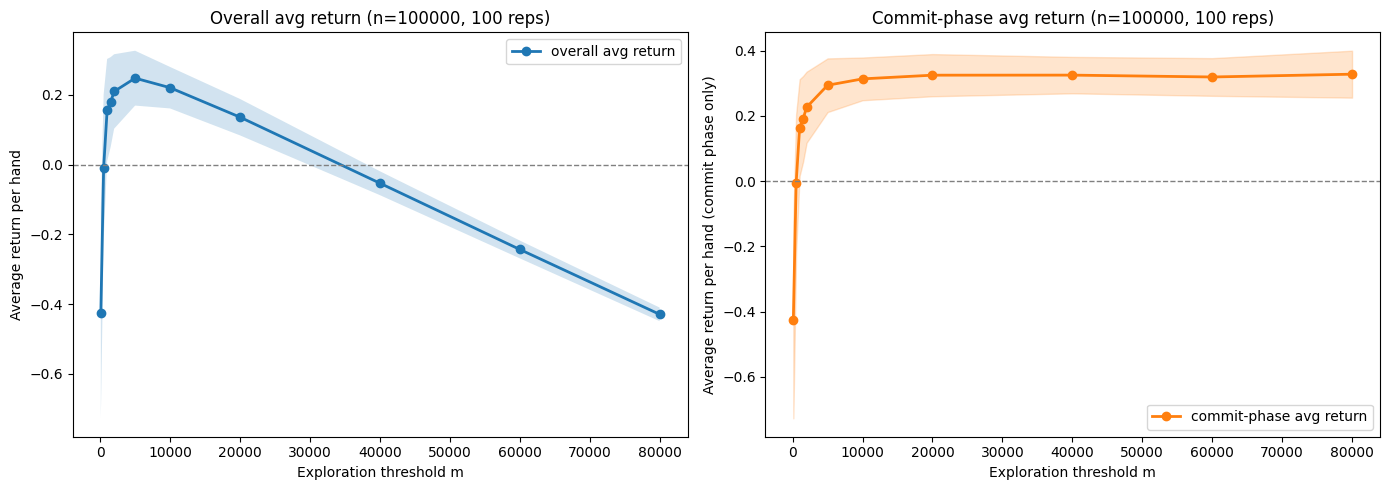

In [28]:
# Run simulation with larger n and m values to get more significant results
data_simplified_large = run_simulation(ETCAgentV2, n=100000, m_values=[100, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000, 60000, 80000])
show(data_simplified_large)


[ETC] Best response built over 147 info sets.
[ETC] Best response built over 177 info sets.
[ETC] Best response built over 204 info sets.
[ETC] Best response built over 156 info sets.
[ETC] Best response built over 129 info sets.
[ETC] Best response built over 210 info sets.
[ETC] Best response built over 153 info sets.
[ETC] Best response built over 153 info sets.
[ETC] Best response built over 165 info sets.
[ETC] Best response built over 189 info sets.
[ETC] Best response built over 210 info sets.
[ETC] Best response built over 177 info sets.
[ETC] Best response built over 162 info sets.
[ETC] Best response built over 165 info sets.
[ETC] Best response built over 129 info sets.
[ETC] Best response built over 150 info sets.
[ETC] Best response built over 168 info sets.
[ETC] Best response built over 198 info sets.
[ETC] Best response built over 204 info sets.
[ETC] Best response built over 141 info sets.
[ETC] Best response built over 144 info sets.
[ETC] Best response built over 186

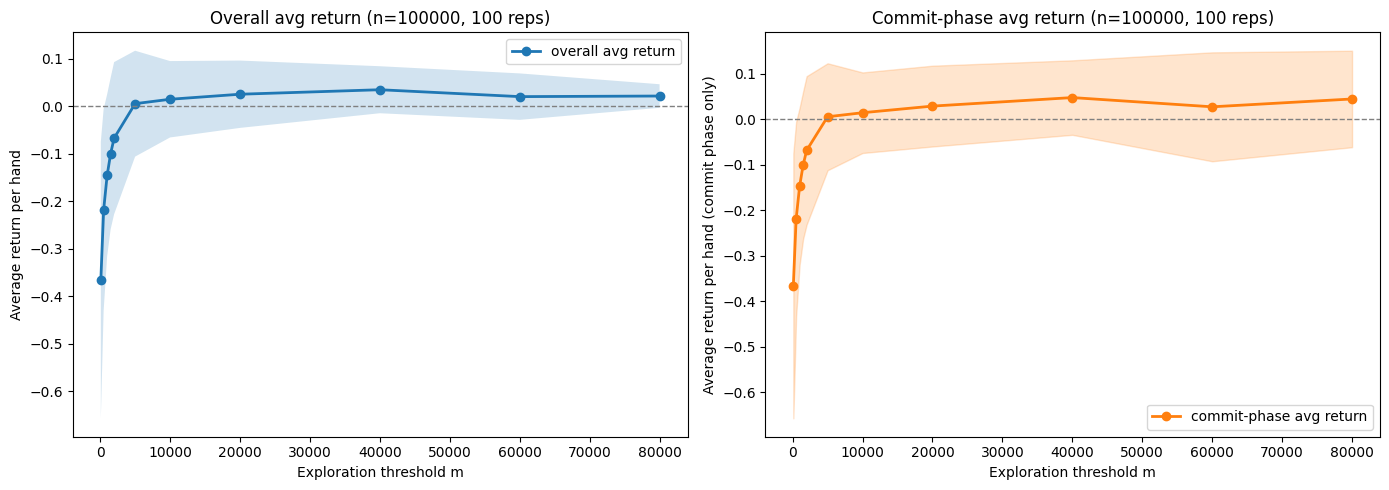

In [25]:
# Do the same for the agent using CFR as exploration strategy
data_simplified_cfr_large = run_simulation(ETCAgentV2, agent_strategy=standard_cfr_policy, n=100000, m_values=[100, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000, 60000, 80000])
show(data_simplified_cfr_large)


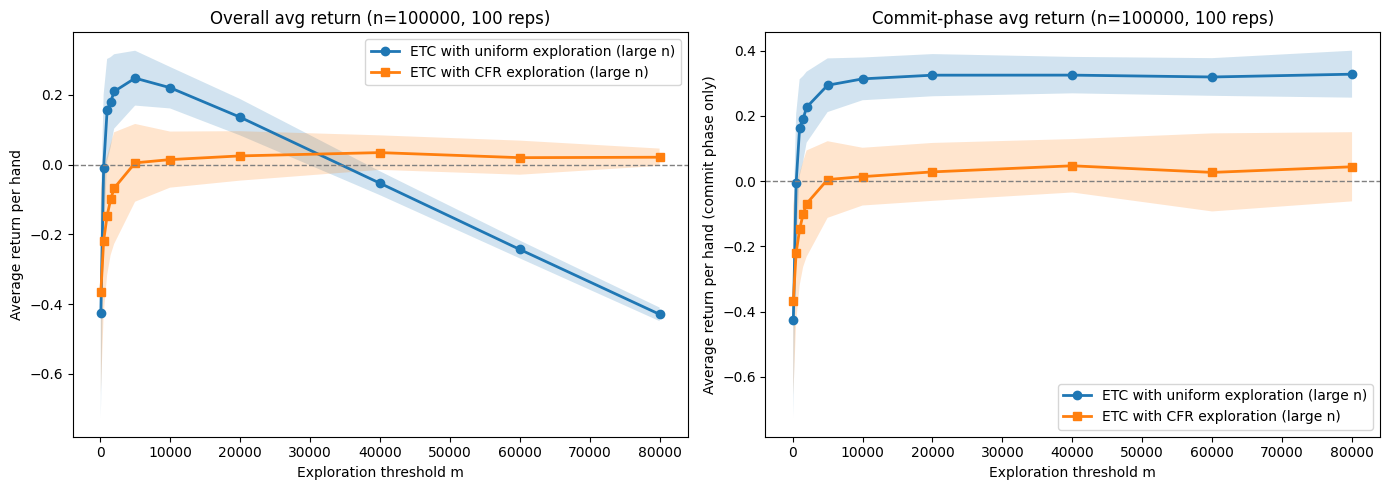

In [29]:
# Compare the two version for the larger n 
compare(data_simplified_large, data_simplified_cfr_large, label1="ETC with uniform exploration (large n)", label2="ETC with CFR exploration (large n)")

[ETC] Best response built over 183 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 207 info sets.
[ETC] Best response built over 189 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 180 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 171 info sets.
[ETC] Best response built over 210 info sets.
[ETC] Best response built over 204 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 201 info sets.
[ETC] Best response built over 207 info sets.
[ETC] Best response built over 204 info sets.
[ETC] Best response built over 210 info sets.
[ETC] Best response built over 207 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 177

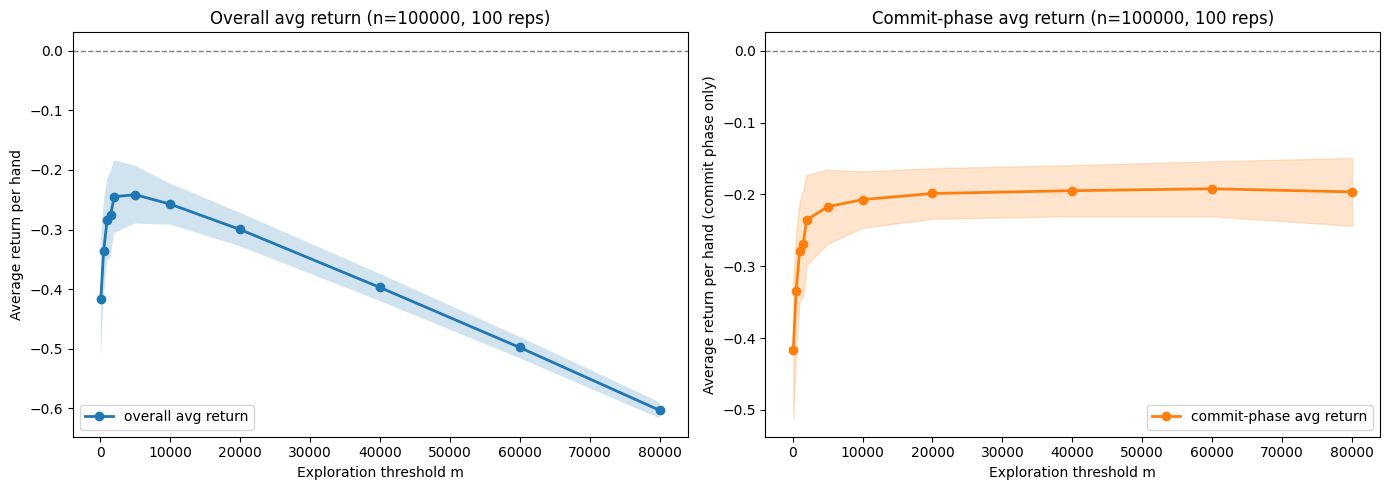

In [35]:
# ETC agent against standard CFR with n = 100000 
data_vs_cfr_large = run_simulation(ETCAgentV2, opponent_strategy=standard_cfr_policy, n=100000, n_repetitions=100, m_values=[100, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000, 60000, 80000])
show(data_vs_cfr_large)

[ETC] Best response built over 240 info sets.
[ETC] Best response built over 207 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 198 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 228 info sets.
[ETC] Best response built over 231 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 222 info sets.
[ETC] Best response built over 204 info sets.
[ETC] Best response built over 225 info sets.
[ETC] Best response built over 210 info sets.
[ETC] Best response built over 213 info sets.
[ETC] Best response built over 192 info sets.
[ETC] Best response built over 216 info sets.
[ETC] Best response built over 216

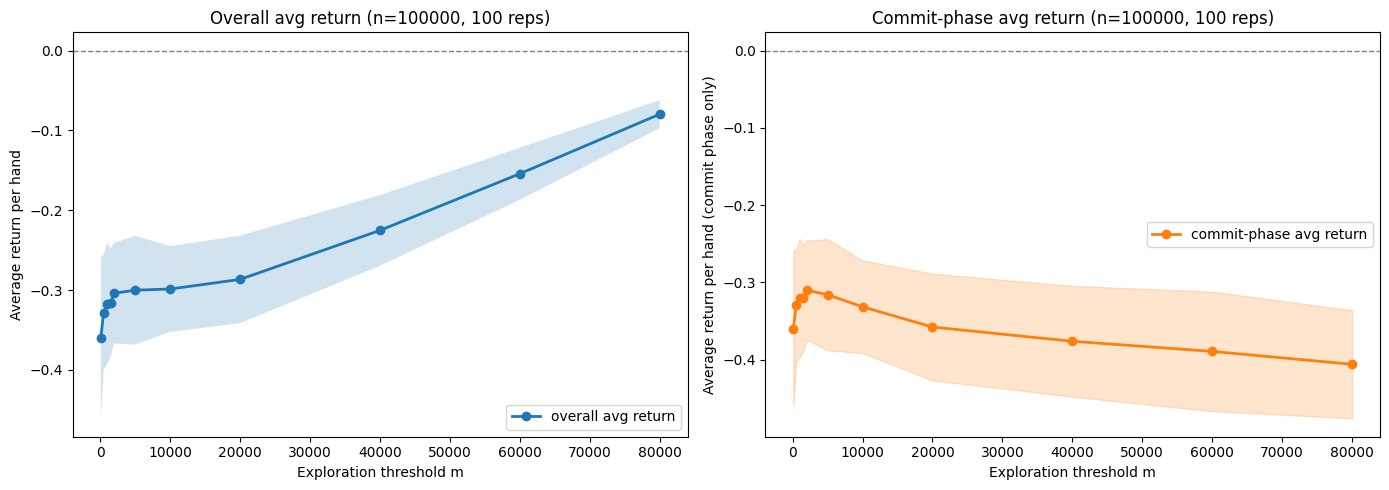

In [38]:
# See if using CFR as exploration strategy gives better results against standard CFR opponent
data_etc_cfr_vs_cfr = run_simulation(ETCAgentV2, agent_strategy=standard_cfr_policy, opponent_strategy=standard_cfr_policy, n=100000, n_repetitions=100, m_values=[100, 500, 1000, 1500, 2000, 5000, 10000, 20000, 40000, 60000, 80000])
show(data_etc_cfr_vs_cfr)

# Store data from each simulation # 

In [36]:
import pandas as pd
import os

RESULTS_CSV = "simulation_results.csv"

def save_simulation(data, name, csv_path=RESULTS_CSV):
    """Save simulation data to CSV. Overwrites any existing rows for `name`."""
    rows = []
    n     = data["n"]
    n_rep = data["n_repetitions"]

    if "m_values" in data:  # run_simulation format
        for m in data["m_values"]:
            for rep_idx, (overall, commit) in enumerate(
                zip(data["results"][m], data["commit_results"][m])
            ):
                rows.append({
                    "simulation_name": name,
                    "sim_type":        "run",
                    "m_value":         m,
                    "rep_index":       rep_idx,
                    "overall_return":  overall,
                    "commit_return":   commit,
                    "n":               n,
                    "n_repetitions":   n_rep,
                })
    else:  # simple_simulation format
        for rep_idx, overall in enumerate(data["results"]):
            rows.append({
                "simulation_name": name,
                "sim_type":        "simple",
                "m_value":         None,
                "rep_index":       rep_idx,
                "overall_return":  overall,
                "commit_return":   None,
                "n":               n,
                "n_repetitions":   n_rep,
            })

    new_df = pd.DataFrame(rows)

    if os.path.exists(csv_path):
        existing = pd.read_csv(csv_path)
        existing = existing[existing["simulation_name"] != name]
        combined = pd.concat([existing, new_df], ignore_index=True)
    else:
        combined = new_df

    combined.to_csv(csv_path, index=False)
    print(f"Saved '{name}' ({len(rows)} rows) → {csv_path}")


def load_simulation(name, csv_path=RESULTS_CSV):
    """Load a simulation by name from the CSV and reconstruct its data dict."""
    df = pd.read_csv(csv_path)
    df = df[df["simulation_name"] == name]
    if df.empty:
        raise ValueError(f"No simulation named '{name}' found in {csv_path}")

    sim_type = df["sim_type"].iloc[0]
    n        = int(df["n"].iloc[0])
    n_rep    = int(df["n_repetitions"].iloc[0])

    if sim_type == "run":
        m_values = sorted(df["m_value"].dropna().unique().astype(int).tolist())
        results, commit_results = {}, {}
        for m in m_values:
            sub = df[df["m_value"] == m].sort_values("rep_index")
            results[m]        = sub["overall_return"].tolist()
            commit_results[m] = sub["commit_return"].tolist()
        return {
            "results":        results,
            "commit_results": commit_results,
            "m_values":       m_values,
            "n":              n,
            "n_repetitions":  n_rep,
        }
    else:
        sub = df.sort_values("rep_index")
        return {
            "results":       sub["overall_return"].tolist(),
            "n":             n,
            "n_repetitions": n_rep,
        }


def list_simulations(csv_path=RESULTS_CSV):
    """Print a summary of all simulations stored in the CSV."""
    if not os.path.exists(csv_path):
        print(f"No CSV found at {csv_path}")
        return
    df = pd.read_csv(csv_path)
    print(df.groupby("simulation_name")[["sim_type", "n", "n_repetitions"]].first().to_string())


In [ ]:
save_simulation(data_cfr_vs_cpt, "cfr_vs_cpt")
save_simulation(data_standard, "etc_standard")
save_simulation(data_simplified, "etc_simplified")
save_simulation(data_simplified_cfr, "etc_simplified_cfr")
save_simulation(data_vs_cfr, "etc_vs_cfr")
save_simulation(data_simplified_large, "etc_simplified_large")
save_simulation(data_simplified_cfr_large, "etc_simplified_cfr_large")
save_simulation(data_vs_cfr_large, "etc_vs_cfr_large")
save_simulation(data_etc_cfr_vs_cfr, "etc_cfr_vs_cfr")

list_simulations()


Saved 'cfr_vs_cpt' (100 rows) → simulation_results.csv
Saved 'etc_standard' (700 rows) → simulation_results.csv
Saved 'etc_simplified' (700 rows) → simulation_results.csv
Saved 'etc_simplified_cfr' (700 rows) → simulation_results.csv
Saved 'etc_vs_cfr' (700 rows) → simulation_results.csv
Saved 'etc_simplified_large' (1100 rows) → simulation_results.csv
Saved 'etc_simplified_cfr_large' (1100 rows) → simulation_results.csv
Saved 'etc_vs_cfr_large' (1100 rows) → simulation_results.csv
                         sim_type       n  n_repetitions
simulation_name                                         
cfr_vs_cpt                 simple  100000            100
etc_simplified                run   10000            100
etc_simplified_cfr            run   10000            100
etc_simplified_cfr_large      run  100000            100
etc_simplified_large          run  100000            100
etc_standard                  run   10000            100
etc_vs_cfr                    run   10000            100
